In [3]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
# Load dataset
data_path = "data/dataset.csv"

if not os.path.exists(data_path):
    alt_path = "../data/dataset.csv"
    if os.path.exists(alt_path):
        data_path = alt_path

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (72946, 10)


,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [5]:
# Basic inspection
print("Columns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

Columns:
['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp', 'crypto_name', 'date']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  str    
 8   crypto_name  72946 non-null  str    
 9   date         72946 non-null  str    
dtypes: float64(6), int64(1), str(3)
memory usage: 8.5 MB


In [6]:
# Cleaning
df = df.copy()

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df["date"] = pd.to_datetime(df["date"], errors="coerce")
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df = df.drop_duplicates()
df = df.sort_values(["crypto_name", "date"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (72946, 9)


,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0.000000,0.516571,0.000000,0.516571,0.000000,0.000000e+00,2020-10-02 23:59:59.999000+00:00,Aave,2020-10-02
1,0.523836,65.305938,0.523801,53.151488,0.000000,0.000000e+00,2020-10-03 23:59:59.999000+00:00,Aave,2020-10-03
2,53.179858,55.070355,50.688990,52.675035,0.000000,0.000000e+00,2020-10-04 23:59:59.999000+00:00,Aave,2020-10-04
3,52.675035,55.112358,49.787900,53.219243,0.000000,8.912813e+07,2020-10-05 23:59:59.999000+00:00,Aave,2020-10-05
4,53.291969,53.402270,40.734578,42.401599,583091.459763,7.101144e+07,2020-10-06 23:59:59.999000+00:00,Aave,2020-10-06


In [7]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values per column:")
print(missing if len(missing) else "No missing values found.")

Missing values per column:
No missing values found.


In [23]:
df.isnull().sum()

open                         0
high                         0
low                          0
close                        0
volume                       0
marketCap                    0
timestamp                    0
crypto_name                  0
date                         0
daily_return                56
price_range                  0
open_close_change            0
volume_marketcap_ratio    2474
realized_volatility_7      386
dtype: int64

In [8]:
# Summary statistics
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
open,72946.0,NaN,NaN,NaN,870.194495,0.0,0.167916,1.630666,26.070557,67549.735581,5231.65447
high,72946.0,NaN,NaN,NaN,896.412386,0.0,0.1768,1.717542,27.568677,162188.255437,5398.612632
low,72946.0,NaN,NaN,NaN,844.06064,0.0,0.15863,1.541486,24.791776,66458.723733,5079.389387
close,72946.0,NaN,NaN,NaN,871.294862,0.0,0.168298,1.640219,26.251951,67566.830088,5235.508138
volume,72946.0,NaN,NaN,NaN,2207607310.505649,0.0,8320617.589204,109875645.955259,669139847.401324,350967941479.059998,9617884904.434078
marketCap,72946.0,NaN,NaN,NaN,14749221288.694319,0.0,186043250.0,1268539252.57233,5118618335.975495,1274831490851.01001,75011591365.807358
timestamp,72946,NaN,NaN,NaN,2019-10-14 03:20:59.944713+00:00,2013-05-05 23:59:59.999000+00:00,2018-09-08 23:59:59.999000+00:00,2020-03-17 23:59:59.999000+00:00,2021-05-02 23:59:59.999000+00:00,2022-10-23 23:59:59.999000+00:00,NaN
crypto_name,72946,56,Bitcoin,3248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,72946,NaN,NaN,NaN,2019-10-13 03:20:59.945713,2013-05-05 00:00:00,2018-09-08 00:00:00,2020-03-17 00:00:00,2021-05-02 00:00:00,2022-10-23 00:00:00,NaN


In [9]:
# Basic feature engineering for EDA
df["daily_return"] = df.groupby("crypto_name")["close"].pct_change()
df["price_range"] = df["high"] - df["low"]
df["open_close_change"] = df["close"] - df["open"]
df["volume_marketcap_ratio"] = df["volume"] / df["marketCap"].replace(0, np.nan)
df["realized_volatility_7"] = df.groupby("crypto_name")["daily_return"].transform(lambda x: x.rolling(7).std())

df.head()

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,daily_return,price_range,open_close_change,volume_marketcap_ratio,realized_volatility_7
0,0.000000,0.516571,0.000000,0.516571,0.000000,0.000000e+00,2020-10-02 23:59:59.999000+00:00,Aave,2020-10-02,NaN,0.516571,0.516571,NaN,NaN
1,0.523836,65.305938,0.523801,53.151488,0.000000,0.000000e+00,2020-10-03 23:59:59.999000+00:00,Aave,2020-10-03,101.892809,64.782137,52.627651,NaN,NaN
2,53.179858,55.070355,50.688990,52.675035,0.000000,0.000000e+00,2020-10-04 23:59:59.999000+00:00,Aave,2020-10-04,-0.008964,4.381366,-0.504823,NaN,NaN
3,52.675035,55.112358,49.787900,53.219243,0.000000,8.912813e+07,2020-10-05 23:59:59.999000+00:00,Aave,2020-10-05,0.010331,5.324459,0.544208,0.000000,NaN
4,53.291969,53.402270,40.734578,42.401599,583091.459763,7.101144e+07,2020-10-06 23:59:59.999000+00:00,Aave,2020-10-06,-0.203266,12.667692,-10.890371,0.008211,NaN


In [10]:
# Data types
df.dtypes

open                                  float64
high                                  float64
low                                   float64
close                                 float64
volume                                float64
marketCap                             float64
timestamp                 datetime64[us, UTC]
crypto_name                               str
date                           datetime64[us]
daily_return                          float64
price_range                           float64
open_close_change                     float64
volume_marketcap_ratio                float64
realized_volatility_7                 float64
dtype: object

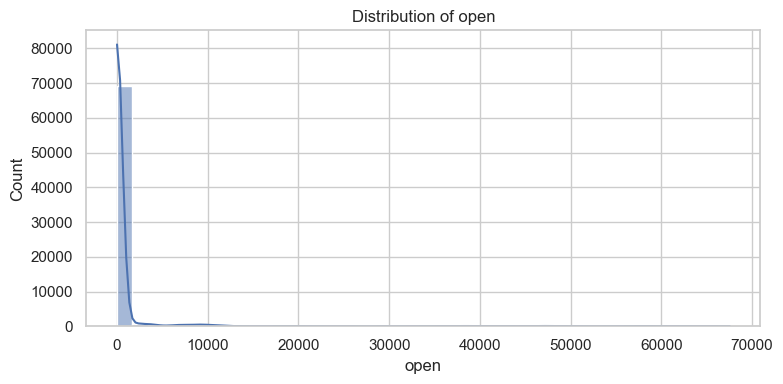

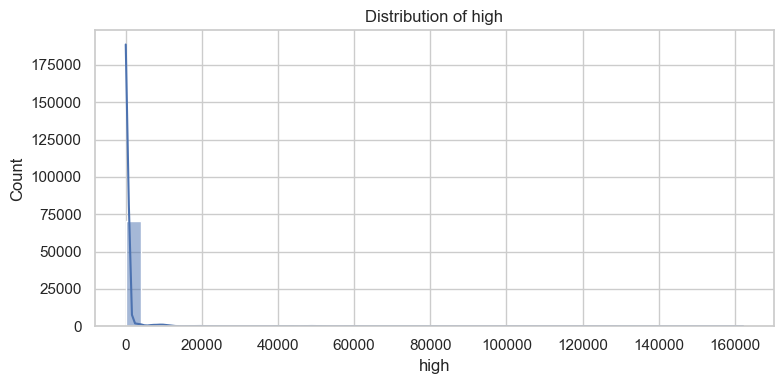

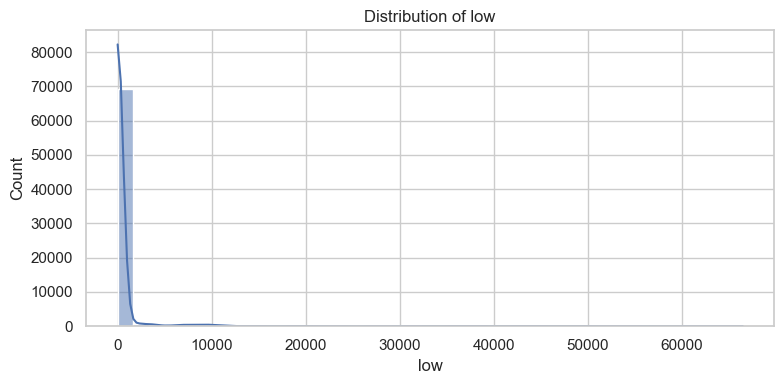

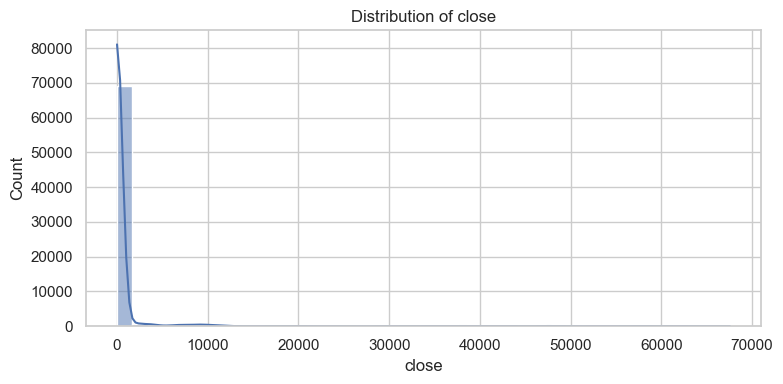

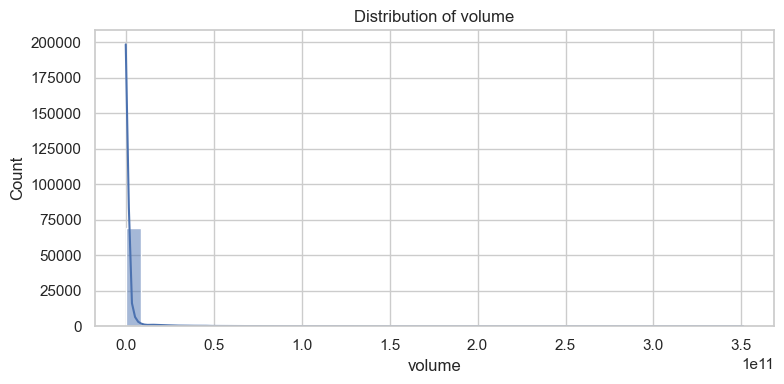

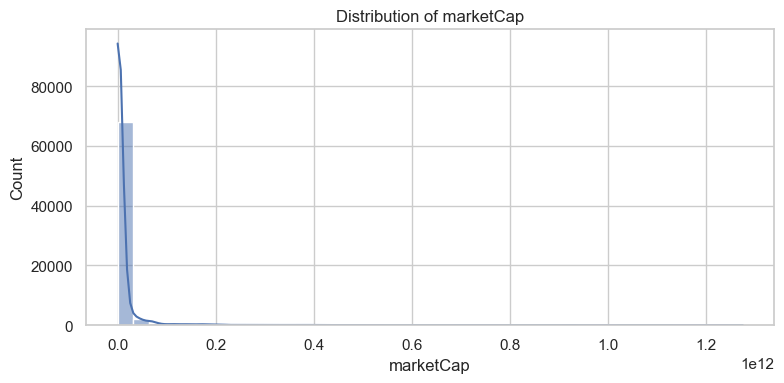

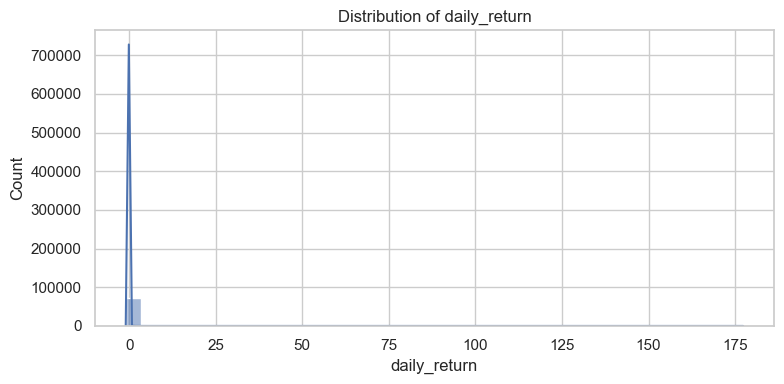

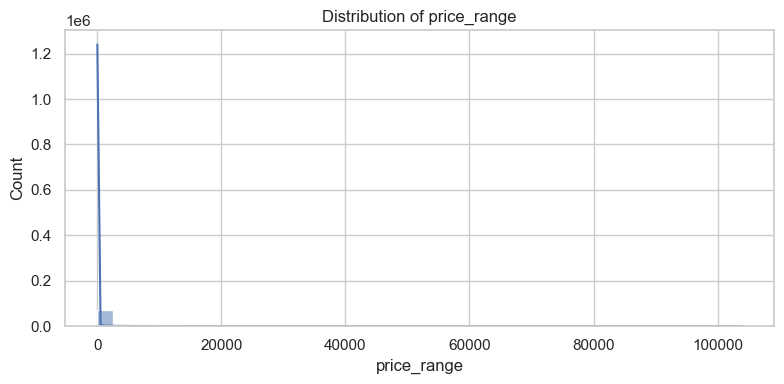

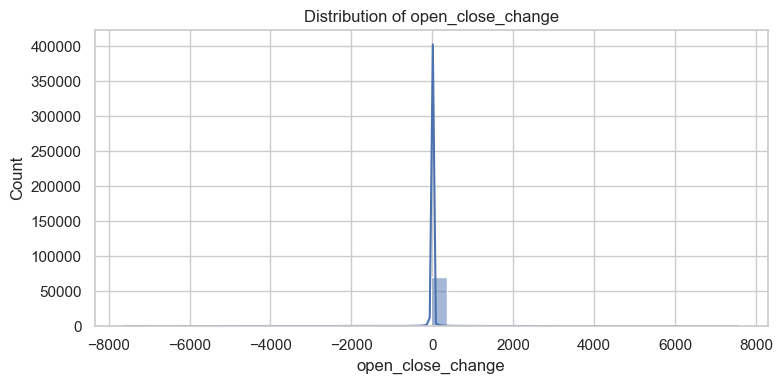

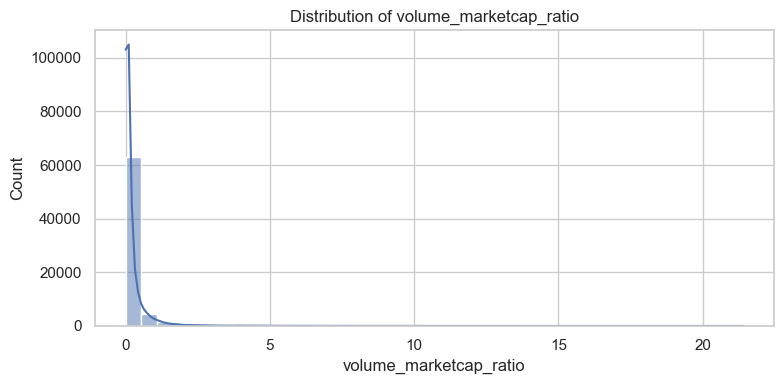

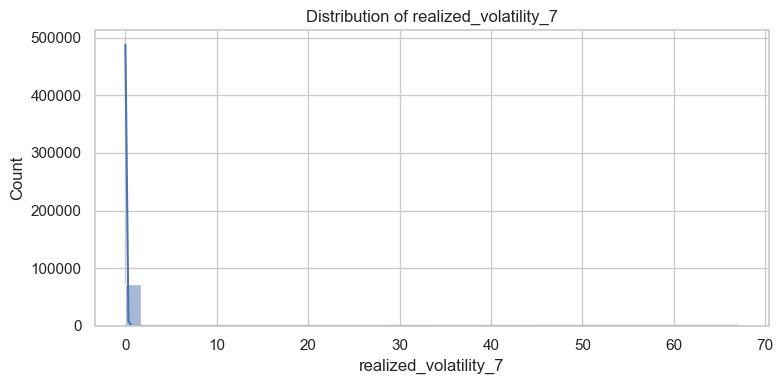

In [11]:
# Distribution plots for key numeric columns
numeric_cols = ["open", "high", "low", "close", "volume", "marketCap", "daily_return", "price_range", "open_close_change", "volume_marketcap_ratio", "realized_volatility_7"]

for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True, bins=40)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

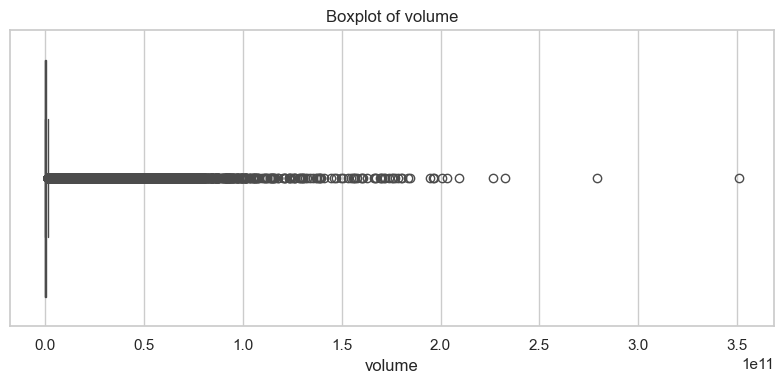

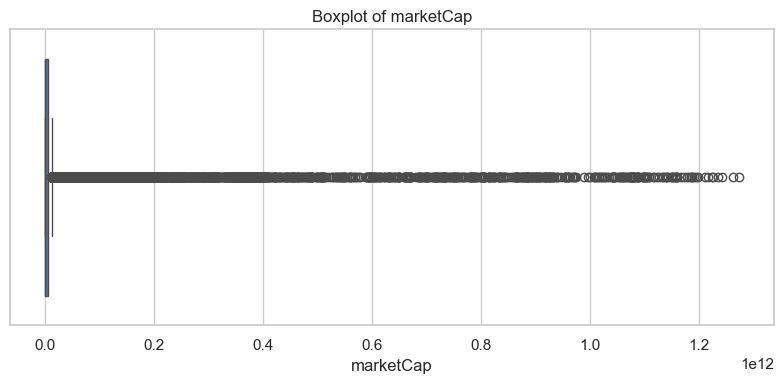

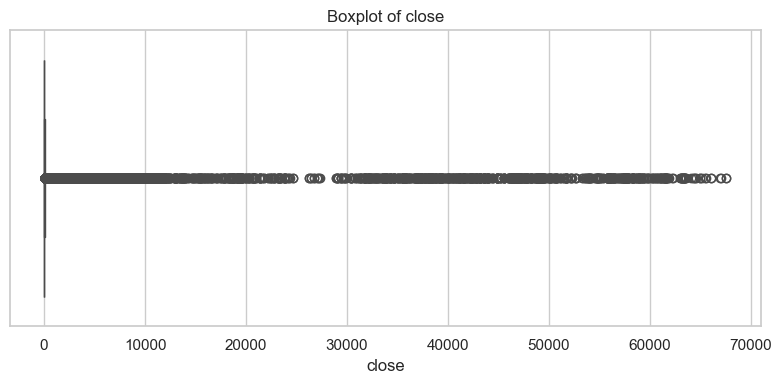

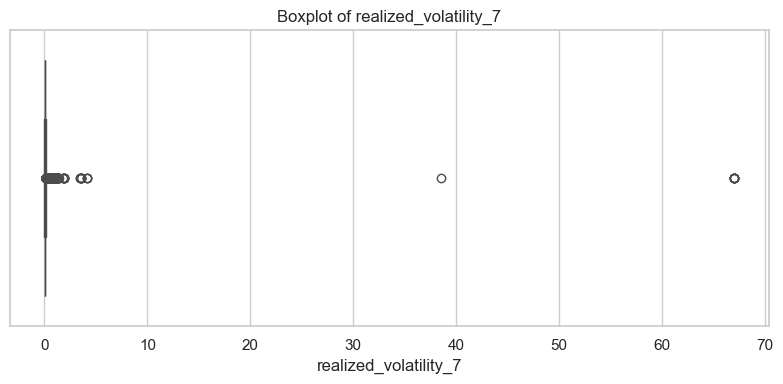

In [12]:
# Boxplots to inspect outliers
for col in ["volume", "marketCap", "close", "realized_volatility_7"]:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.tight_layout()
        plt.show()

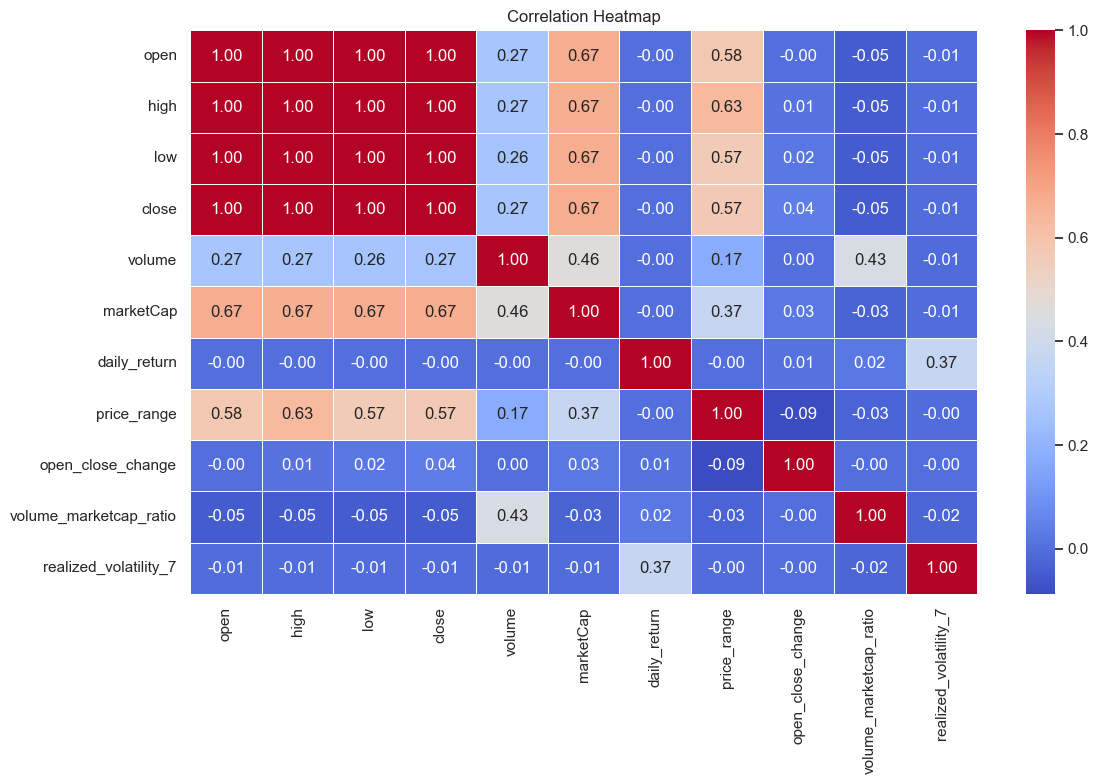

In [13]:
# Correlation heatmap
corr_cols = [
    "open", "high", "low", "close", "volume", "marketCap",
    "daily_return", "price_range", "open_close_change",
    "volume_marketcap_ratio", "realized_volatility_7"
]

corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

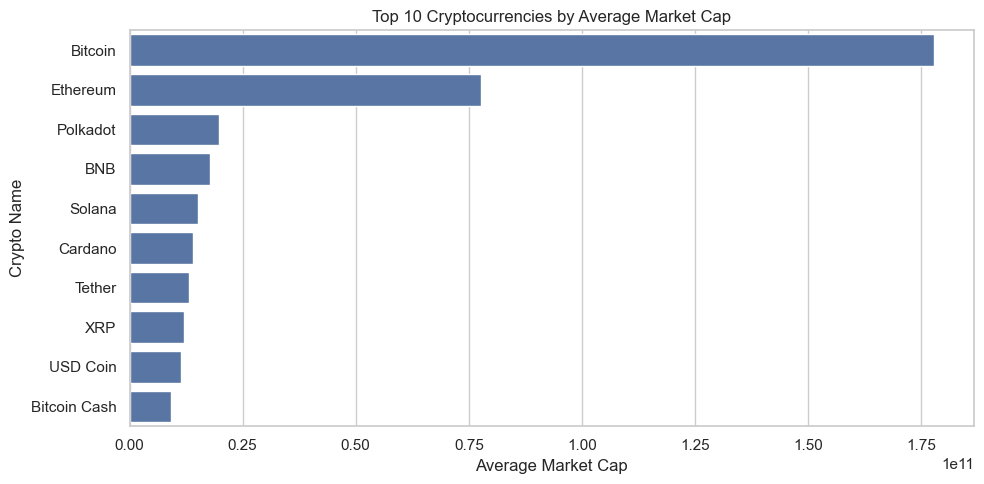

crypto_name
Bitcoin         1.777921e+11
Ethereum        7.763656e+10
Polkadot        1.971862e+10
BNB             1.774417e+10
Solana          1.521559e+10
Cardano         1.407725e+10
Tether          1.318953e+10
XRP             1.214154e+10
USD Coin        1.146844e+10
Bitcoin Cash    9.151862e+09
Name: marketCap, dtype: float64

In [14]:
# Top cryptocurrencies by average market cap
top_marketcap = (
    df.groupby("crypto_name")["marketCap"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_marketcap.values, y=top_marketcap.index)
plt.title("Top 10 Cryptocurrencies by Average Market Cap")
plt.xlabel("Average Market Cap")
plt.ylabel("Crypto Name")
plt.tight_layout()
plt.show()

top_marketcap

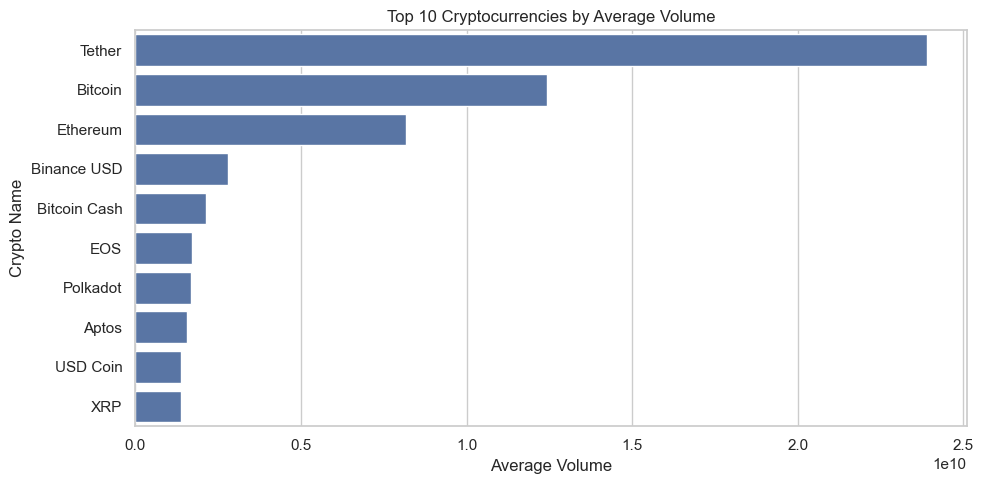

crypto_name
Tether          2.390698e+10
Bitcoin         1.243484e+10
Ethereum        8.157793e+09
Binance USD     2.781233e+09
Bitcoin Cash    2.132186e+09
EOS             1.694873e+09
Polkadot        1.691899e+09
Aptos           1.563615e+09
USD Coin        1.385022e+09
XRP             1.369413e+09
Name: volume, dtype: float64

In [15]:
# Top cryptocurrencies by average trading volume
top_volume = (
    df.groupby("crypto_name")["volume"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_volume.values, y=top_volume.index)
plt.title("Top 10 Cryptocurrencies by Average Volume")
plt.xlabel("Average Volume")
plt.ylabel("Crypto Name")
plt.tight_layout()
plt.show()

top_volume

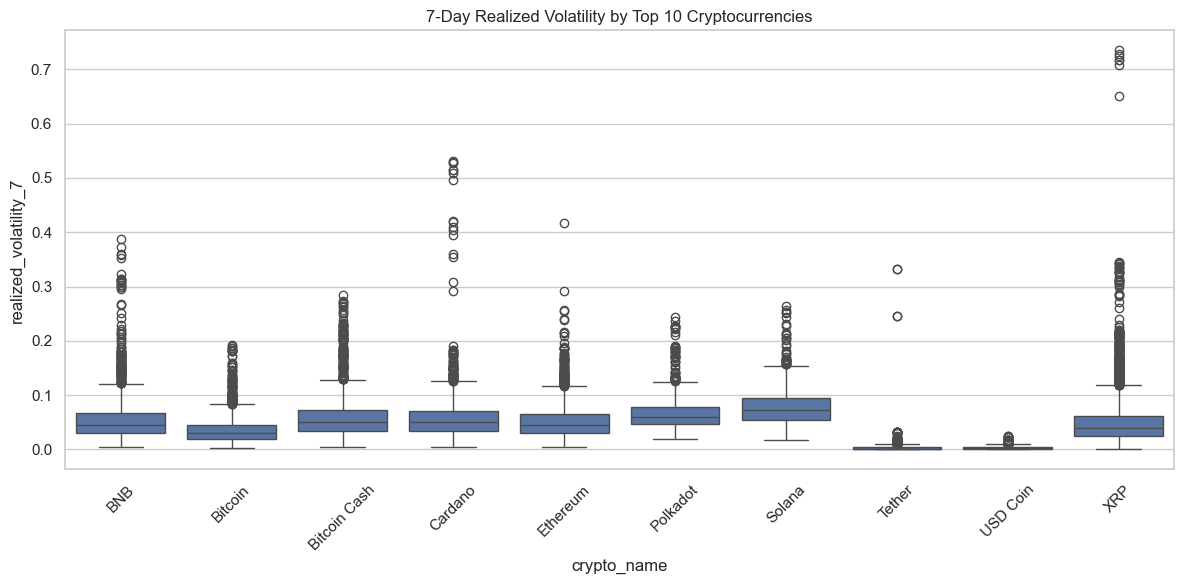

In [16]:
# Volatility distribution by crypto (top 10 by market cap)
top_10_crypto = top_marketcap.index.tolist()
vol_df = df[df["crypto_name"].isin(top_10_crypto)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=vol_df, x="crypto_name", y="realized_volatility_7")
plt.xticks(rotation=45)
plt.title("7-Day Realized Volatility by Top 10 Cryptocurrencies")
plt.tight_layout()
plt.show()

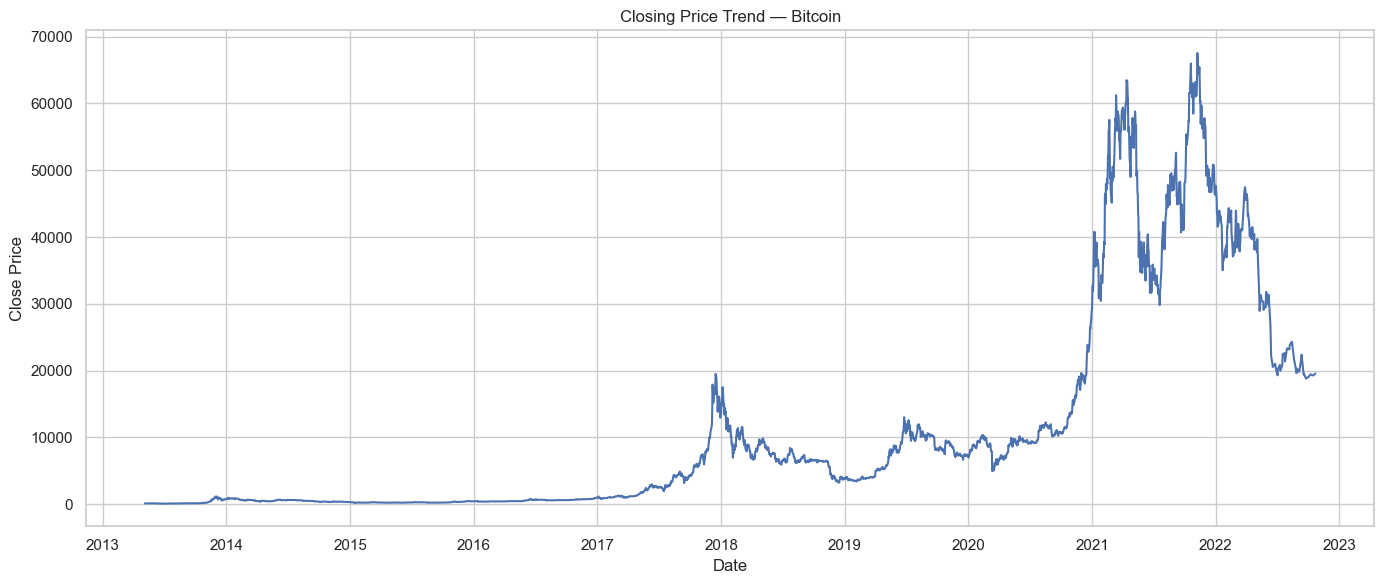

In [17]:
# Price trend for Bitcoin if present, otherwise first available crypto
crypto_choice = "Bitcoin" if "Bitcoin" in df["crypto_name"].unique() else df["crypto_name"].dropna().unique()[0]
crypto_df = df[df["crypto_name"] == crypto_choice].copy()

plt.figure(figsize=(14, 6))
sns.lineplot(data=crypto_df, x="date", y="close")
plt.title(f"Closing Price Trend — {crypto_choice}")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.tight_layout()
plt.show()

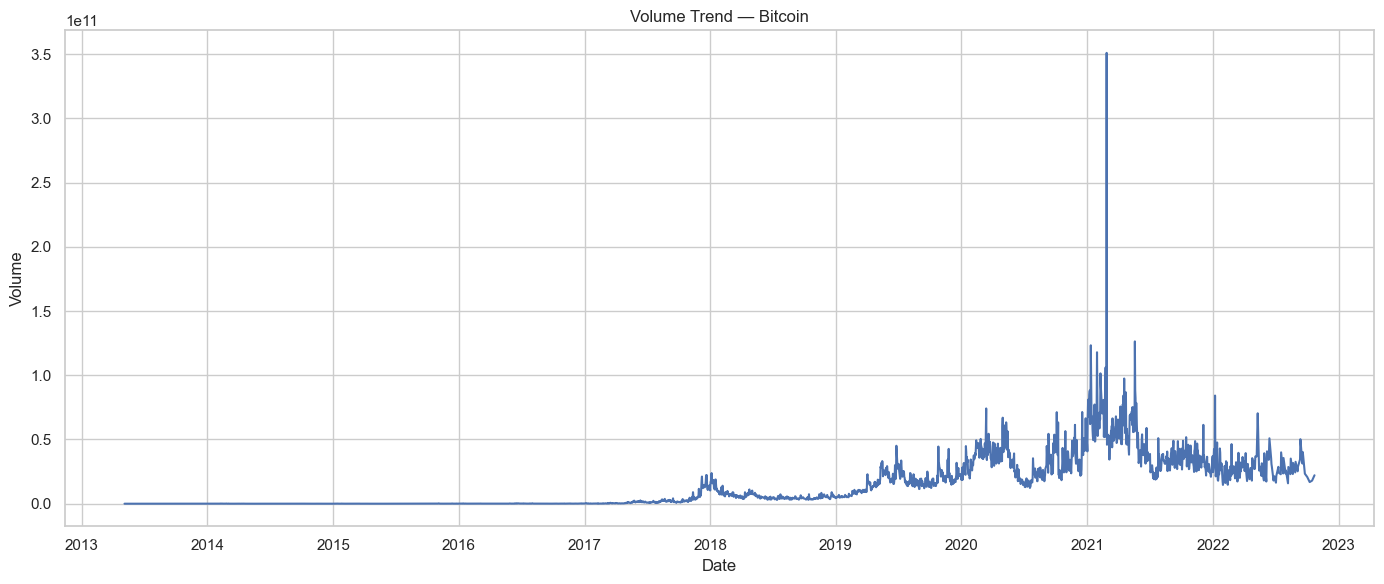

In [18]:
# Volume trend for the selected crypto
plt.figure(figsize=(14, 6))
sns.lineplot(data=crypto_df, x="date", y="volume")
plt.title(f"Volume Trend — {crypto_choice}")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

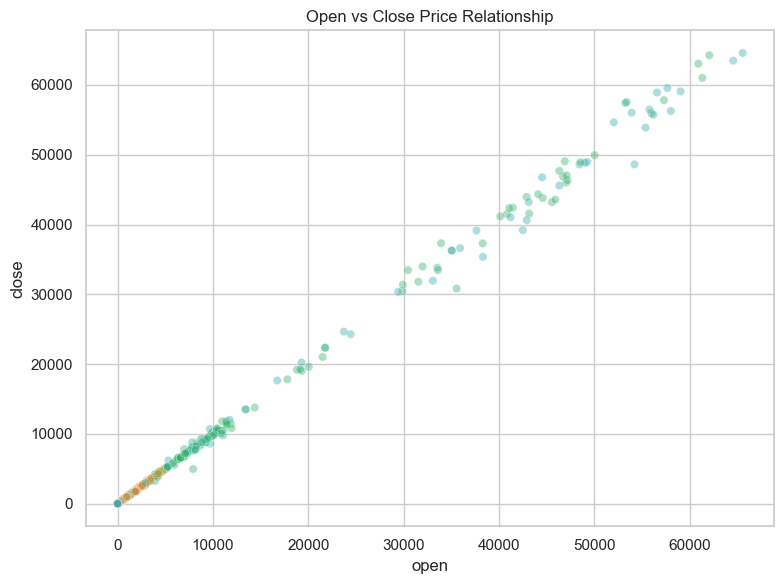

In [19]:
# Open vs Close scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x="open", y="close", hue="crypto_name", legend=False, alpha=0.4)
plt.title("Open vs Close Price Relationship")
plt.tight_layout()
plt.show()

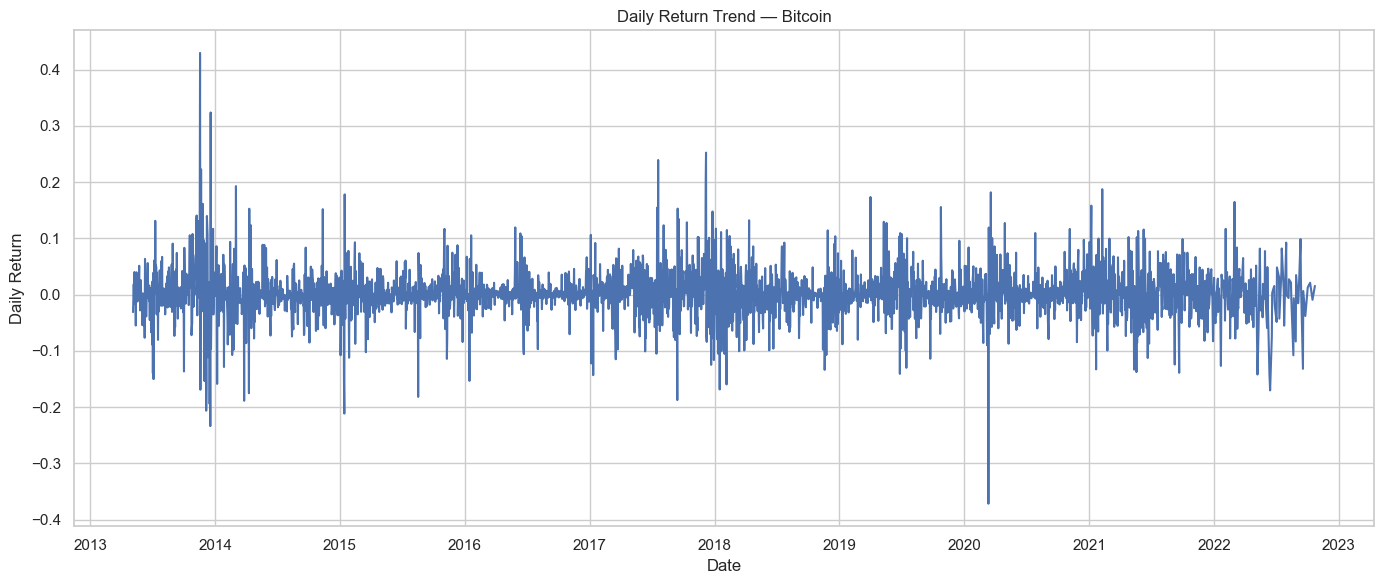

In [20]:
# Daily return trend for selected crypto
plt.figure(figsize=(14, 6))
sns.lineplot(data=crypto_df, x="date", y="daily_return")
plt.title(f"Daily Return Trend — {crypto_choice}")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.tight_layout()
plt.show()

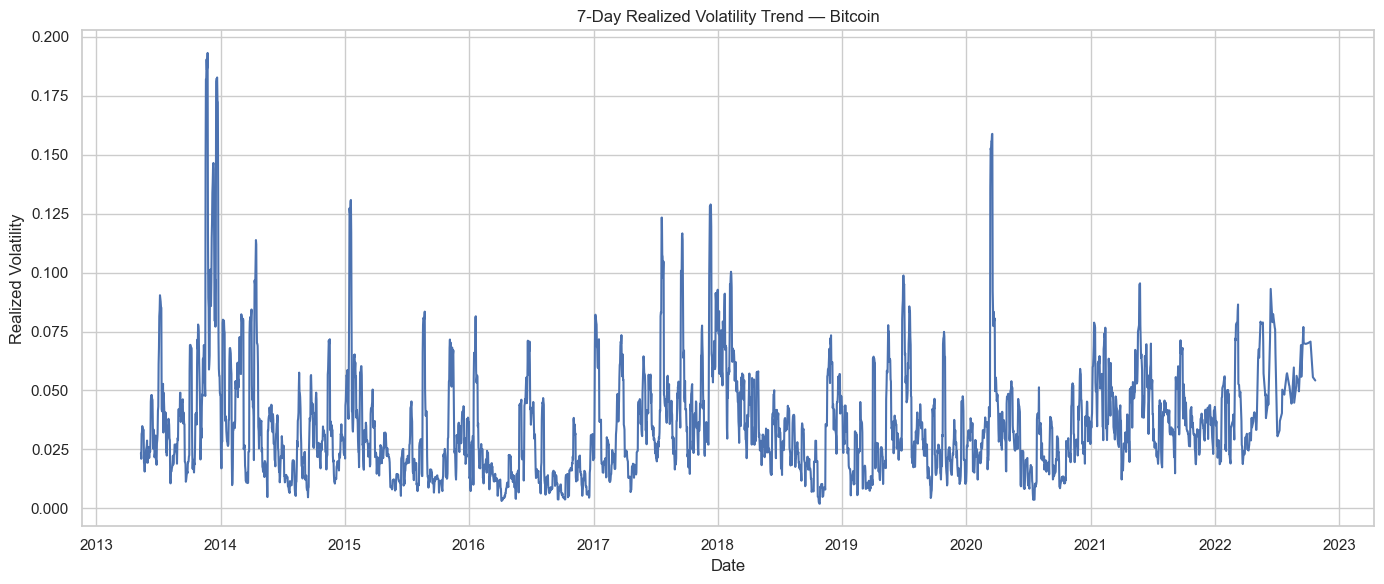

In [21]:
# Volatility over time for selected crypto
plt.figure(figsize=(14, 6))
sns.lineplot(data=crypto_df, x="date", y="realized_volatility_7")
plt.title(f"7-Day Realized Volatility Trend — {crypto_choice}")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.tight_layout()
plt.show()

In [22]:
# Final EDA summary table
summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "crypto_count",
        "date_min",
        "date_max",
        "missing_values"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        df["crypto_name"].nunique(),
        df["date"].min(),
        df["date"].max(),
        int(df.isnull().sum().sum())
    ]
})

summary

,metric,value
0,rows,72946
1,columns,14
2,crypto_count,56
3,date_min,2013-05-05 00:00:00
4,date_max,2022-10-23 00:00:00
5,missing_values,2916
